In [4]:
!pip install numpy pandas matplotlib scikit-learn
!pip install torch torchvision torchaudio
!pip install seaborn jupyterlab

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
from sklearn.metrics import mean_squared_error

Veri Yükleme
Amazon hisse fiyatları CSV dosyasından okunuyor.

In [6]:
df = pd.read_csv("D:\Sema\StockPrice\AMZN_2006-01-01_to_2018-01-01.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,47.47,47.85,46.25,47.58,7582127,AMZN
1,2006-01-04,47.48,47.73,46.69,47.25,7440914,AMZN
2,2006-01-05,47.16,48.20,47.11,47.65,5417258,AMZN
3,2006-01-06,47.97,48.58,47.32,47.87,6154285,AMZN
4,2006-01-09,46.55,47.10,46.40,47.08,8945056,AMZN


Veri Ön İşleme  
Kapanış fiyatları -1 ile 1 aralığına ölçekleniyor ve model için giriş/çıkış dizileri oluşturuluyor.

In [7]:
# Veriyi -1 ile 1 aralığına ölçekliyoruz
scaler = MinMaxScaler(feature_range=(-1,1))
close_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [8]:
# 20 günlük geçmiş veriyi kullanarak tahmin dizileri oluşturuyoruz
lookback = 20
X, y = [], []

for i in range(len(close_data) - lookback):
    X.append(close_data[i:i+lookback])
    y.append(close_data[i+lookback])

X = np.array(X)
y = np.array(y)

Model Tanımı  
LSTM ve GRU modelleri zaman serisi tahmini için oluşturulacak.
Model, Mean Squared Error (MSE) kayıp fonksiyonu ve Adam optimizasyon algoritması ile eğitiliyor.  
Her epoch sonunda loss değeri yazdırılarak öğrenme süreci takip ediliyor.

In [9]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel()

In [11]:
criterion = nn.MSELoss()  # Kayıp fonksiyonu: Ortalama Kare Hata
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizasyon algoritması

for epoch in range(10):
    for X_batch, y_batch in loader:
        optimizer.zero_grad() # Önceki gradyanları sıfırla
        output = model(X_batch) # Model tahmini yap
        loss = criterion(output, y_batch) # Kayıp hesapla
        loss.backward()  # Geriye yayılım
        optimizer.step()  # Ağırlıkları güncelle
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
print("done")

Epoch 1, Loss: 0.0021
Epoch 2, Loss: 0.0006
Epoch 3, Loss: 0.0002
Epoch 4, Loss: 0.0002
Epoch 5, Loss: 0.0004
Epoch 6, Loss: 0.0005
Epoch 7, Loss: 0.0004
Epoch 8, Loss: 0.0005
Epoch 9, Loss: 0.0004
Epoch 10, Loss: 0.0007
done


In [12]:
model.eval()  # Modeli değerlendirme moduna alıyoruz
with torch.no_grad():   # Gradyan hesaplamayı kapatıyoruz (tahmin için)
    predictions = model(X_tensor).numpy()   # Model tahminleri

# Ölçeklendirmeyi geri alarak gerçek fiyat aralığına dönüyoruz
predicted_prices = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_tensor.numpy())

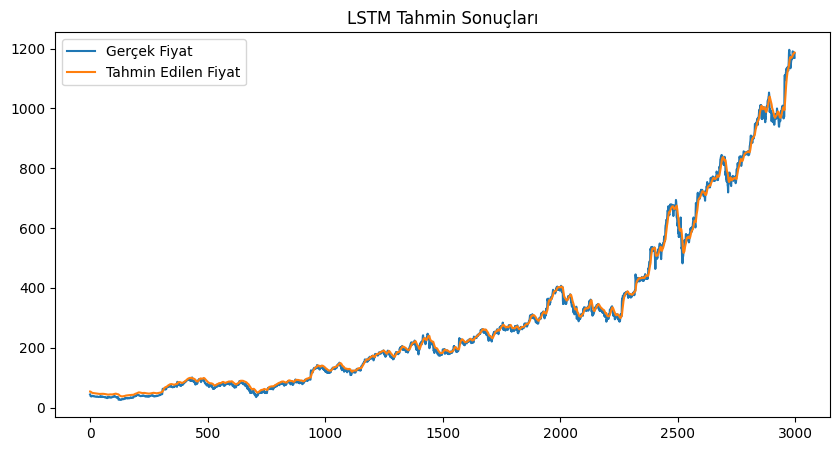

In [13]:
# Tahmin ve gerçek fiyatları görselleştiriyoruz
plt.figure(figsize=(10,5))
plt.plot(actual_prices, label="Gerçek Fiyat")
plt.plot(predicted_prices, label="Tahmin Edilen Fiyat")
plt.legend()
plt.title("LSTM Tahmin Sonuçları")
plt.show()

Model Değerlendirme  
Eğitilen LSTM modeli test verisi üzerinde değerlendirilmiştir.  
Grafikte mavi çizgi gerçek fiyatları, turuncu çizgi ise modelin tahmin ettiği fiyatları göstermektedir.  
Modelin tahminleri gerçek değerlere oldukça yakın olduğundan, öğrenme süreci başarılı görünmektedir.

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

GRU Modeli Eğitimi  
GRU (Gated Recurrent Unit) modeli, LSTM’e benzer şekilde zaman serisi tahmini için kullanılır.  
Bu model, geçmiş 20 günlük kapanış fiyatlarını kullanarak bir sonraki günü tahmin etmeyi amaçlar.  
Aşağıdaki hücrede model, MSE kayıp fonksiyonu ve Adam optimizasyon algoritması ile eğitilmektedir.

In [15]:
# GRU modelini tanımlıyoruz
gru_model = GRUModel()
# Kayıp fonksiyonu ve optimizasyon algoritması
criterion = nn.MSELoss()  # Ortalama Kare Hata
optimizer = optim.Adam(gru_model.parameters(), lr=0.001)  # Adam optimizer

# Modeli 10 epoch boyunca eğitiyoruz
for epoch in range(10):
    for X_batch, y_batch in loader:
        optimizer.zero_grad() # Gradyanları sıfırla
        output = gru_model(X_batch)  # Model tahmini
        loss = criterion(output, y_batch)  # Kayıp hesapla
        loss.backward()  # Geriye yayılım
        optimizer.step()  # Ağırlıkları güncelle
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
print("done")

Epoch 1, Loss: 0.0042
Epoch 2, Loss: 0.0004
Epoch 3, Loss: 0.0008
Epoch 4, Loss: 0.0004
Epoch 5, Loss: 0.0003
Epoch 6, Loss: 0.0002
Epoch 7, Loss: 0.0001
Epoch 8, Loss: 0.0003
Epoch 9, Loss: 0.0002
Epoch 10, Loss: 0.0002
done


In [16]:
gru_model.eval() # Modeli değerlendirme moduna alıyoruz
with torch.no_grad():  # Gradyan hesaplamayı kapatıyoruz (tahmin için)
    # Ölçeklendirmeyi geri alarak gerçek fiyat aralığına dönüyoruz
    gru_predictions = gru_model(X_tensor).numpy()  # Model tahminleri

gru_predicted_prices = scaler.inverse_transform(gru_predictions)

GRU Modeli Değerlendirme  
Eğitilen GRU modeli test verisi üzerinde değerlendirilmiştir.  
Grafikte mavi çizgi gerçek fiyatları, turuncu çizgi ise GRU modelinin tahmin ettiği fiyatları göstermektedir.  
Tahminler genel olarak gerçek değerlere yakın olduğundan modelin öğrenme süreci başarılı görünmektedir.

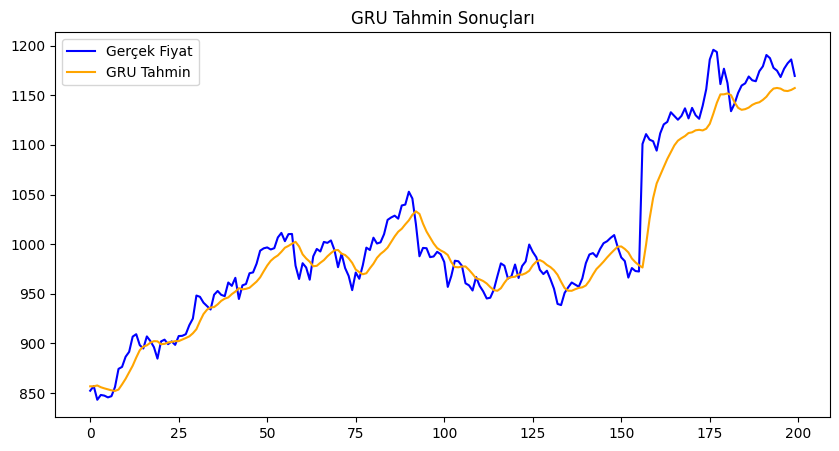

In [17]:
plt.figure(figsize=(10,5))
plt.plot(actual_prices[-200:], label="Gerçek Fiyat", color="blue")
plt.plot(gru_predicted_prices[-200:], label="GRU Tahmin", color="orange")
plt.legend()
plt.title("GRU Tahmin Sonuçları")
plt.show()

LSTM ve GRU Tahmin Karşılaştırması  
Bu grafikte LSTM ve GRU modellerinin tahmin performansları karşılaştırılmaktadır.  
Mavi çizgi gerçek fiyatları, yeşil çizgi LSTM tahminlerini, turuncu çizgi ise GRU tahminlerini göstermektedir.  
Her iki model de benzer sonuçlar üretmiş olup, GRU modeli biraz daha hızlı öğrenme eğilimi göstermektedir.

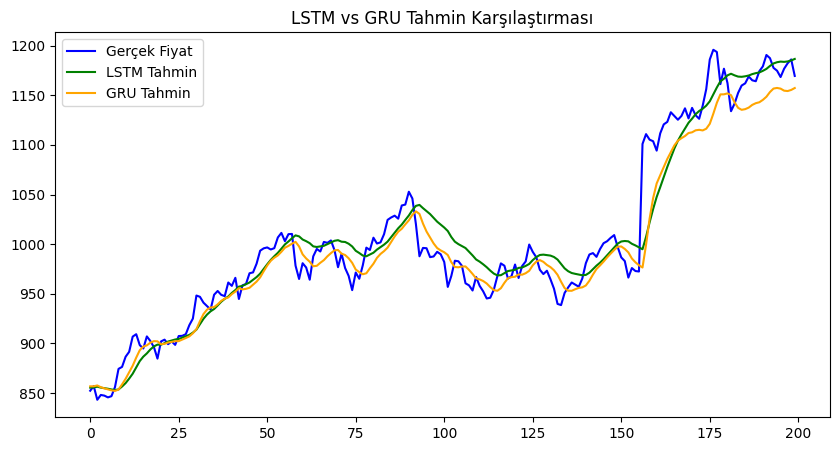

In [18]:
plt.figure(figsize=(10,5))
plt.plot(actual_prices[-200:], label="Gerçek Fiyat", color="blue")
plt.plot(predicted_prices[-200:], label="LSTM Tahmin", color="green")
plt.plot(gru_predicted_prices[-200:], label="GRU Tahmin", color="orange")
plt.legend()
plt.title("LSTM vs GRU Tahmin Karşılaştırması")
plt.show()

Sonuç  
LSTM ve GRU modelleri, Amazon hisse fiyatlarını tahmin etmede başarılı sonuçlar vermiştir.  
Her iki modelin hataları (MSE) birbirine yakın olup, GRU modeli daha düşük MSE değeriyle biraz daha iyi performans göstermiştir.  
Bu çalışma, zaman serisi tahminlerinde RNN tabanlı modellerin güçlü bir alternatif olduğunu göstermektedir.

Model Performans Değerlendirmesi  
LSTM ve GRU modellerinin tahmin performansları Mean Squared Error (MSE) metriği ile karşılaştırılmıştır.  
MSE değeri ne kadar düşükse, modelin tahminleri gerçek değerlere o kadar yakındır.  
Aşağıdaki çıktılar, GRU modelinin LSTM’e göre biraz daha düşük hata oranına sahip olduğunu göstermektedir.

In [19]:
# Her iki model için MSE (Mean Squared Error) hesaplanıyor
mse_lstm = mean_squared_error(actual_prices, predicted_prices)
mse_gru = mean_squared_error(actual_prices, gru_predicted_prices)

print("LSTM MSE:", mse_lstm)
print("GRU MSE:", mse_gru)

LSTM MSE: 167.90335083007812
GRU MSE: 115.50923156738281


In [20]:
num_epochs = 50  # Eğitim süresi (epoch sayısı)
loss_values = [] # Her epoch için ortalama loss değerlerini tutmak için liste

for epoch in range(num_epochs):
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()  # Gradyanları sıfırla
        output = model(X_batch)  # Model tahmini
        loss = criterion(output, y_batch)  # Kayıp hesapla
        loss.backward()  # Geriye yayılım
        optimizer.step()  # Ağırlıkları güncelleb
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    loss_values.append(avg_loss)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")
print("done")

Epoch 1, Avg Loss: 0.0005
Epoch 2, Avg Loss: 0.0005
Epoch 3, Avg Loss: 0.0005
Epoch 4, Avg Loss: 0.0005
Epoch 5, Avg Loss: 0.0005
Epoch 6, Avg Loss: 0.0005
Epoch 7, Avg Loss: 0.0005
Epoch 8, Avg Loss: 0.0005
Epoch 9, Avg Loss: 0.0005
Epoch 10, Avg Loss: 0.0005
Epoch 11, Avg Loss: 0.0005
Epoch 12, Avg Loss: 0.0005
Epoch 13, Avg Loss: 0.0005
Epoch 14, Avg Loss: 0.0005
Epoch 15, Avg Loss: 0.0005
Epoch 16, Avg Loss: 0.0005
Epoch 17, Avg Loss: 0.0005
Epoch 18, Avg Loss: 0.0005
Epoch 19, Avg Loss: 0.0005
Epoch 20, Avg Loss: 0.0005
Epoch 21, Avg Loss: 0.0005
Epoch 22, Avg Loss: 0.0005
Epoch 23, Avg Loss: 0.0005
Epoch 24, Avg Loss: 0.0005
Epoch 25, Avg Loss: 0.0005
Epoch 26, Avg Loss: 0.0005
Epoch 27, Avg Loss: 0.0005
Epoch 28, Avg Loss: 0.0005
Epoch 29, Avg Loss: 0.0005
Epoch 30, Avg Loss: 0.0005
Epoch 31, Avg Loss: 0.0005
Epoch 32, Avg Loss: 0.0005
Epoch 33, Avg Loss: 0.0005
Epoch 34, Avg Loss: 0.0005
Epoch 35, Avg Loss: 0.0005
Epoch 36, Avg Loss: 0.0005
Epoch 37, Avg Loss: 0.0005
Epoch 38, 

Eğitim Kayıp Eğrisi  
Modelin eğitim sürecindeki kayıp değerlerinin değişimi görselleştirilecektir.  
Bu grafik, modelin öğrenme sürecinin istikrarlı olup olmadığını anlamamıza yardımcı olur.

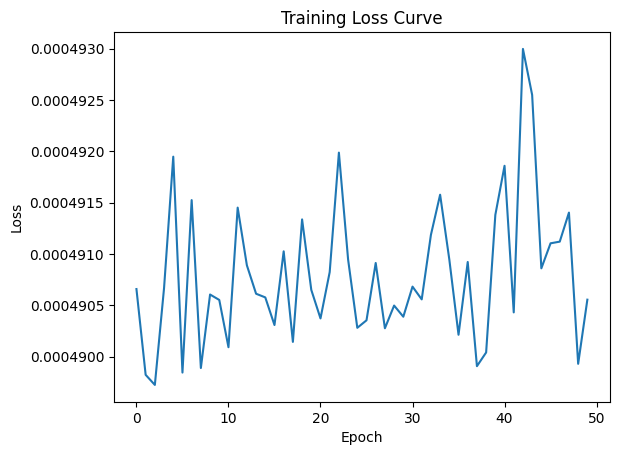

In [21]:
plt.plot(loss_values)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

Learning Rate Denemeleri  
Bu bölümde LSTM modelinin farklı öğrenme oranları (learning rate) ile eğitimi test edilmektedir.  
Amaç, hangi öğrenme oranının en düşük kayıp (loss) değerini verdiğini gözlemlemektir.  
Grafikte her öğrenme oranı için loss eğrisi ayrı bir renkle gösterilecektir.


Deneme: lr=0.0005
Epoch 1, Avg Loss: 0.2342
Epoch 2, Avg Loss: 0.0127
Epoch 3, Avg Loss: 0.0015
Epoch 4, Avg Loss: 0.0008
Epoch 5, Avg Loss: 0.0007
Epoch 6, Avg Loss: 0.0007
Epoch 7, Avg Loss: 0.0007
Epoch 8, Avg Loss: 0.0006
Epoch 9, Avg Loss: 0.0006
Epoch 10, Avg Loss: 0.0007
Epoch 11, Avg Loss: 0.0006
Epoch 12, Avg Loss: 0.0006
Epoch 13, Avg Loss: 0.0006
Epoch 14, Avg Loss: 0.0006
Epoch 15, Avg Loss: 0.0006
Epoch 16, Avg Loss: 0.0006
Epoch 17, Avg Loss: 0.0006
Epoch 18, Avg Loss: 0.0006
Epoch 19, Avg Loss: 0.0005
Epoch 20, Avg Loss: 0.0005

Deneme: lr=0.001
Epoch 1, Avg Loss: 0.1663
Epoch 2, Avg Loss: 0.0043
Epoch 3, Avg Loss: 0.0008
Epoch 4, Avg Loss: 0.0006
Epoch 5, Avg Loss: 0.0006
Epoch 6, Avg Loss: 0.0006
Epoch 7, Avg Loss: 0.0006
Epoch 8, Avg Loss: 0.0006
Epoch 9, Avg Loss: 0.0006
Epoch 10, Avg Loss: 0.0005
Epoch 11, Avg Loss: 0.0005
Epoch 12, Avg Loss: 0.0006
Epoch 13, Avg Loss: 0.0005
Epoch 14, Avg Loss: 0.0005
Epoch 15, Avg Loss: 0.0005
Epoch 16, Avg Loss: 0.0005
Epoch 17,

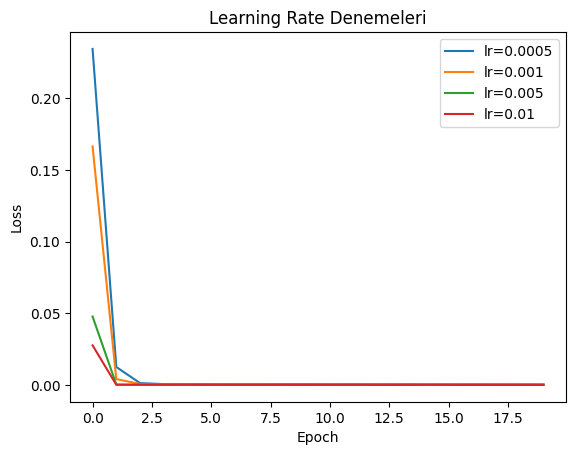

In [22]:
# Farklı öğrenme oranlarını test ediyoruz
for lr in [0.0005, 0.001, 0.005, 0.01]:
    print(f"\nDeneme: lr={lr}")
    model = LSTMModel()  # Yeni model oluştur
    optimizer = optim.Adam(model.parameters(), lr=lr)  # Adam optimizer ile öğrenme oranını ayarla
    loss_values = []
    
    # Modeli 20 epoch boyunca eğit
    for epoch in range(20):
        total_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        loss_values.append(avg_loss)
        print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")
    plt.plot(loss_values, label=f"lr={lr}") # Her öğrenme oranı için loss eğrisini çiz

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Rate Denemeleri")
plt.legend()
plt.show()

Model Kaydetme  
Eğitilen LSTM modelinin ağırlıkları `.pth` dosyasına kaydedilmiştir.  
Bu sayede model daha sonra yeniden yüklenip tahminlerde kullanılabilir.

In [25]:
torch.save(model.state_dict(), "lstm_model_day20.pth")

Eğitim ve Test Verisinin Ayrılması  
Veri setinin %80'i eğitim, %20'si test için ayrılmıştır.  
Bu adım, modelin genelleme yeteneğini değerlendirmek için gereklidir.

In [26]:
train_size = int(len(X_tensor) * 0.8)

X_train = X_tensor[:train_size]
X_test  = X_tensor[train_size:]

y_train = y_tensor[:train_size]
y_test  = y_tensor[train_size:]

In [27]:
# TensorDataset ve DataLoader oluşturuyoruz
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [31]:
import time

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Modeli 100 epoch boyunca eğitiyoruz
num_epochs = 100
train_losses = []

for epoch in range(num_epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

end = time.time()
print("LSTM Tam Eğitim Bitti")
print("LSTM Training süresi:", end - start, "saniye")

Epoch 1, Avg Loss: 0.1615
Epoch 2, Avg Loss: 0.0059
Epoch 3, Avg Loss: 0.0008
Epoch 4, Avg Loss: 0.0005
Epoch 5, Avg Loss: 0.0005
Epoch 6, Avg Loss: 0.0004
Epoch 7, Avg Loss: 0.0004
Epoch 8, Avg Loss: 0.0004
Epoch 9, Avg Loss: 0.0004
Epoch 10, Avg Loss: 0.0004
Epoch 11, Avg Loss: 0.0004
Epoch 12, Avg Loss: 0.0003
Epoch 13, Avg Loss: 0.0003
Epoch 14, Avg Loss: 0.0003
Epoch 15, Avg Loss: 0.0003
Epoch 16, Avg Loss: 0.0003
Epoch 17, Avg Loss: 0.0003
Epoch 18, Avg Loss: 0.0003
Epoch 19, Avg Loss: 0.0003
Epoch 20, Avg Loss: 0.0002
Epoch 21, Avg Loss: 0.0002
Epoch 22, Avg Loss: 0.0002
Epoch 23, Avg Loss: 0.0002
Epoch 24, Avg Loss: 0.0002
Epoch 25, Avg Loss: 0.0003
Epoch 26, Avg Loss: 0.0002
Epoch 27, Avg Loss: 0.0002
Epoch 28, Avg Loss: 0.0002
Epoch 29, Avg Loss: 0.0002
Epoch 30, Avg Loss: 0.0002
Epoch 31, Avg Loss: 0.0002
Epoch 32, Avg Loss: 0.0002
Epoch 33, Avg Loss: 0.0002
Epoch 34, Avg Loss: 0.0002
Epoch 35, Avg Loss: 0.0002
Epoch 36, Avg Loss: 0.0002
Epoch 37, Avg Loss: 0.0002
Epoch 38, 

GRU Modeli Tam Eğitim  
Bu bölümde GRU modeli, LSTM modeline benzer şekilde 100 epoch boyunca eğitilmektedir.  
Amaç, GRU’nun zaman serisi tahmin performansını LSTM ile karşılaştırmaktır.  
Eğitim sonunda ortalama kayıp (loss) değerleri yazdırılarak modelin öğrenme süreci gözlemlenir.

In [32]:
import time

# GRU modelini tanımlıyoru
gru_model = GRUModel()
# Kayıp fonksiyonu ve optimizasyon algoritması
criterion = nn.MSELoss() # Ortalama Kare Hata
optimizer = optim.Adam(gru_model.parameters(), lr=0.001) # Adam optimizer

# Modeli 100 epoch boyunca eğitiyoruz
num_epochs = 100
start = time.time()
gru_train_losses = []

for epoch in range(num_epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = gru_model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward() # Geriye yayılım
        optimizer.step() # Ağırlıkları güncelle
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    gru_train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

end = time.time()
print("GRU Tam Eğitim Bitti")
print("GRU Training süresi:", end - start, "saniye")

Epoch 1, Avg Loss: 0.1155
Epoch 2, Avg Loss: 0.0099
Epoch 3, Avg Loss: 0.0005
Epoch 4, Avg Loss: 0.0003
Epoch 5, Avg Loss: 0.0003
Epoch 6, Avg Loss: 0.0002
Epoch 7, Avg Loss: 0.0002
Epoch 8, Avg Loss: 0.0002
Epoch 9, Avg Loss: 0.0002
Epoch 10, Avg Loss: 0.0002
Epoch 11, Avg Loss: 0.0002
Epoch 12, Avg Loss: 0.0002
Epoch 13, Avg Loss: 0.0002
Epoch 14, Avg Loss: 0.0002
Epoch 15, Avg Loss: 0.0001
Epoch 16, Avg Loss: 0.0001
Epoch 17, Avg Loss: 0.0001
Epoch 18, Avg Loss: 0.0002
Epoch 19, Avg Loss: 0.0001
Epoch 20, Avg Loss: 0.0001
Epoch 21, Avg Loss: 0.0001
Epoch 22, Avg Loss: 0.0001
Epoch 23, Avg Loss: 0.0001
Epoch 24, Avg Loss: 0.0001
Epoch 25, Avg Loss: 0.0001
Epoch 26, Avg Loss: 0.0001
Epoch 27, Avg Loss: 0.0001
Epoch 28, Avg Loss: 0.0001
Epoch 29, Avg Loss: 0.0001
Epoch 30, Avg Loss: 0.0001
Epoch 31, Avg Loss: 0.0001
Epoch 32, Avg Loss: 0.0001
Epoch 33, Avg Loss: 0.0001
Epoch 34, Avg Loss: 0.0001
Epoch 35, Avg Loss: 0.0001
Epoch 36, Avg Loss: 0.0001
Epoch 37, Avg Loss: 0.0001
Epoch 38, 

GRU Modeli Eğitim ve Test Kayıpları  
Bu bölümde GRU modelinin her epoch sonunda hem eğitim hem test kayıpları hesaplanmaktadır.  
Amaç, modelin öğrenme sürecini ve genelleme yeteneğini gözlemlemektir.  
Eğitim kaybı modelin veriyi ne kadar iyi öğrendiğini, test kaybı ise aşırı öğrenme (overfitting) olup olmadığını gösterir.

In [33]:
train_losses = [] # Her epoch için eğitim kayıplarını tutar
test_losses = []   # Her epoch için test kayıplarını tutar
num_epochs = 100

for epoch in range(num_epochs):
    model.train() # Modeli eğitim moduna al
    total_train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

In [34]:
 # Test döngüsü
model.eval() # Modeli değerlendirme moduna al
total_test_loss = 0
with torch.no_grad(): # Gradyan hesaplamayı kapat
    for X_batch, y_batch in test_loader:
        output = model(X_batch)
        loss = criterion(output, y_batch)
        total_test_loss += loss.item()
avg_test_loss = total_test_loss / len(test_loader)
test_losses.append(avg_test_loss)

Eğitim ve Test Kayıp Eğrisi  
Bu grafik, modelin her epoch sonunda eğitim ve test kayıplarının değişimini göstermektedir.  
Eğitim kaybının düşmesi modelin veriyi öğrenmesini, test kaybının düşük kalması ise genelleme başarısını gösterir.  
Eğer test kaybı eğitim kaybına göre çok yükselirse, model aşırı öğrenme (overfitting) yapıyor olabilir.

In [35]:
train_losses.append(avg_train_loss)
test_losses.append(avg_test_loss)

print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

Epoch 100, Train Loss: 0.0002, Test Loss: 0.0071


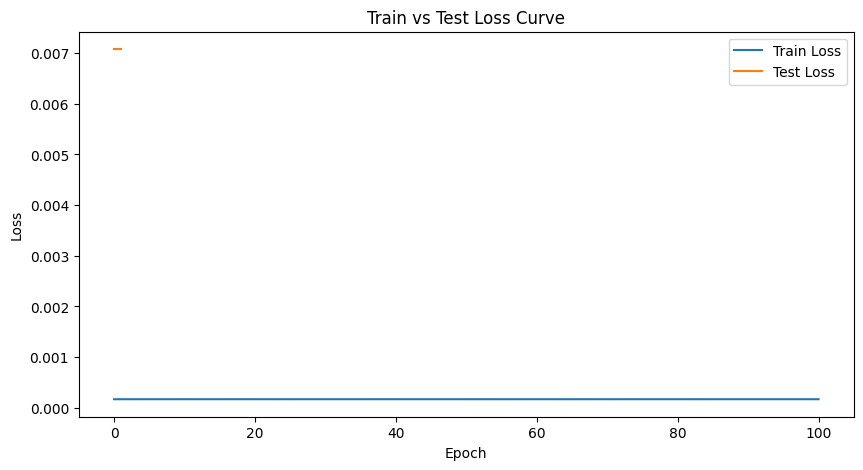

In [36]:
plt.figure(figsize=(10,5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss Curve")
plt.legend()
plt.show()

In [37]:
print("Train Loss uzunluğu:", len(train_losses))
print("Test Loss uzunluğu:", len(test_losses))
print("Train Loss örnekleri:", train_losses[:5])
print("Test Loss örnekleri:", test_losses[:5])

Train Loss uzunluğu: 101
Test Loss uzunluğu: 2
Train Loss örnekleri: [0.00016911999303071448, 0.0001691397756803781, 0.0001691179207409732, 0.0001691448075386385, 0.00016912863298784942]
Test Loss örnekleri: [0.007075180605936207, 0.007075180605936207]


Model Tahminleri  
Eğitilen LSTM ve GRU modelleri test verisi üzerinde tahmin yapmaktadır.  
Tahmin edilen değerler, ölçeklendirme işlemi geri alınarak gerçek fiyat aralığına dönüştürülmüştür.  
Bu adım, modellerin gerçek fiyatlarla ne kadar uyumlu tahminler yaptığını görmemizi sağlar.

In [39]:
model.eval()
gru_model.eval()

with torch.no_grad():
    lstm_preds = model(X_test).numpy()  # LSTM tahminleri
    gru_preds = gru_model(X_test).numpy()  # GRU tahminleri

# Ölçeklendirmeyi geri alarak gerçek fiyat aralığına dönüyoruz
lstm_pred_prices = scaler.inverse_transform(lstm_preds)
gru_pred_prices  = scaler.inverse_transform(gru_preds)
actual_prices    = scaler.inverse_transform(y_test.numpy())

In [40]:
model.eval()
gru_model.eval()

with torch.no_grad():
    lstm_preds = model(X_test).numpy()
    gru_preds  = gru_model(X_test).numpy()

lstm_pred_prices = scaler.inverse_transform(lstm_preds)
gru_pred_prices  = scaler.inverse_transform(gru_preds)
actual_prices    = scaler.inverse_transform(y_test.numpy())

Model Performans Değerlendirmesi  
LSTM ve GRU modellerinin tahmin performansları Mean Squared Error (MSE) metriği ile karşılaştırılmaktadır.  
MSE değeri ne kadar düşükse, modelin tahminleri gerçek değerlere o kadar yakındır.  
Bu karşılaştırma, hangi modelin daha doğru tahminler yaptığını sayısal olarak gösterir.

In [41]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Her iki model için MSE hesaplanıyor
mse_lstm = mean_squared_error(actual_prices, lstm_pred_prices)
mse_gru  = mean_squared_error(actual_prices, gru_pred_prices)

# Karekök alarak RMSE (Root Mean Squared Error) hesaplıyoruz
rmse_lstm = np.sqrt(mse_lstm)
rmse_gru  = np.sqrt(mse_gru)

print("LSTM MSE:", mse_lstm)
print("GRU MSE:", mse_gru)
print("LSTM RMSE:", rmse_lstm)
print("GRU RMSE:", rmse_gru)

LSTM MSE: 2204.1396484375
GRU MSE: 382.75518798828125
LSTM RMSE: 46.94826565952676
GRU RMSE: 19.564130136253983


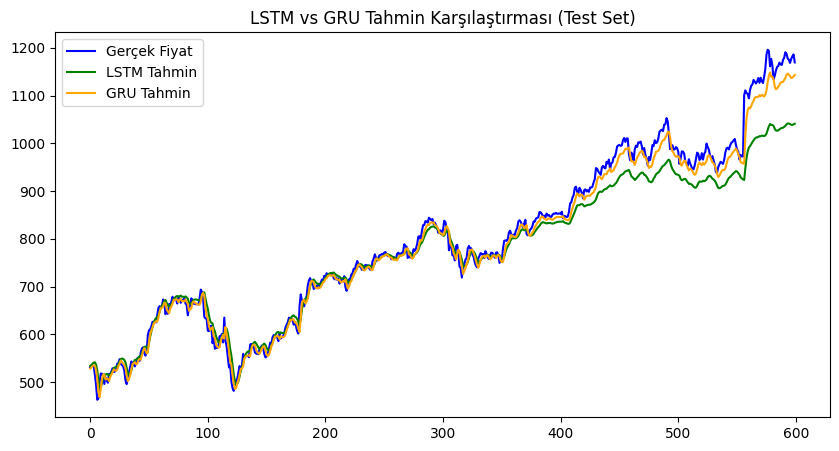

In [42]:
plt.figure(figsize=(10,5))
plt.plot(actual_prices, label="Gerçek Fiyat", color="blue")
plt.plot(lstm_pred_prices, label="LSTM Tahmin", color="green")
plt.plot(gru_pred_prices, label="GRU Tahmin", color="orange")
plt.legend()
plt.title("LSTM vs GRU Tahmin Karşılaştırması (Test Set)")
plt.show()

Sonuç  
Her iki model de zaman serisi tahmininde başarılı sonuçlar vermiştir.  
Ancak GRU modeli, daha düşük MSE ve RMSE değerleriyle LSTM’e göre daha iyi performans göstermiştir.  
Bu çalışma, GRU’nun daha hızlı öğrenme ve daha az parametreyle benzer doğruluk sağlayabileceğini göstermektedir.

Lookback Değerlerinin Etkisi  
Bu bölümde LSTM modelinin farklı lookback (geri bakış) değerleriyle performansı test edilmektedir.  
Lookback, modelin geçmiş kaç gün veriyi kullanarak tahmin yaptığı parametredir.  
Amaç, hangi lookback değerinin en düşük MSE ile en iyi tahmin performansını verdiğini bulmaktır.

In [44]:
lookbacks = [10, 20, 60]  # Farklı lookback değerleri
mse_results = {}  # Her lookback için MSE sonuçlarını tutmak için sözlük

for lb in lookbacks:
    X, y = [], []
    # Veriyi lookback uzunluğuna göre oluştur
    for i in range(len(close_data) - lb):
        X.append(close_data[i:i+lb])
        y.append(close_data[i+lb])
    X = np.array(X)
    y = np.array(y)

    # Tensor dönüşümü
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    # Model tanımı ve eğitimi
    model = LSTMModel()
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(30):
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

    # Modeli değerlendirme
    model.eval()
    with torch.no_grad():
        preds = model(X_tensor).numpy()
    mse = mean_squared_error(scaler.inverse_transform(y_tensor.numpy()),
                             scaler.inverse_transform(preds))
    mse_results[lb] = mse # Sonucu kaydet
    print(f"Lookback={lb}, MSE={mse:.4f}")

Lookback=10, MSE=151.3034
Lookback=20, MSE=103.6859
Lookback=60, MSE=116.4183


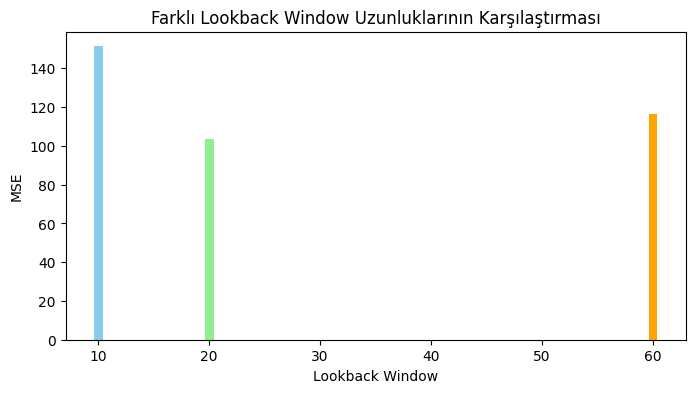

In [45]:
plt.figure(figsize=(8,4))
plt.bar(list(mse_results.keys()), list(mse_results.values()),
        color=['skyblue','lightgreen','orange'])
plt.xlabel("Lookback Window")
plt.ylabel("MSE")
plt.title("Farklı Lookback Window Uzunluklarının Karşılaştırması")
plt.show()